# CIC Interpolation Filter

A **Cascaded Integrator-Comb (CIC)** interpolation filter converts a signal from a low sample rate $f_s$ to a higher rate $M \cdot f_s$ without multipliers — making it extremely hardware-friendly.

## Structure

```
x[n]  →  [Comb ×N]  →  [↑M]  →  [Integrator ×N]  →  y[n]
(low rate)                                             (high rate)
```

The order of comb and integrator is **swapped** compared to decimation:
1. **N comb stages** run at the **low** sample rate: $H_\text{comb}(z) = 1 - z^{-1}$
2. **Upsample by M** (insert $M-1$ zeros between every input sample)
3. **N integrator stages** run at the **high** sample rate: $H_\text{int}(z) = \dfrac{1}{1-z^{-1}}$

## Transfer Function

The combined transfer function (in the high-rate $z$-domain) is:

$$H(z) = \left(\frac{1-z^{-M}}{1-z^{-1}}\right)^N = \left(\sum_{k=0}^{M-1} z^{-k}\right)^N$$

This is equivalent to $N$ cascaded **moving-average (box) filters** of length $M$, each running at the high rate.

The magnitude response is:

$$\left|H(e^{j\omega})\right| = \left|\frac{\sin(M\omega/2)}{\sin(\omega/2)}\right|^N$$

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, lfilter

## Implementation

Two equivalent implementations are shown:
- **Direct cascade** — comb stages → upsample → integrator stages (efficient, matches hardware)
- **Moving-average equivalent** — convolve with a box filter of length $M$ (useful for verification)

In [25]:
def upsample(x, M):
    """Insert M-1 zeros between every sample."""
    out = np.zeros(len(x) * M)
    out[::M] = x
    return out


def cic_interp(x, M, N=1):
    """
    CIC interpolation filter.
    x : input signal at low sample rate
    M : interpolation factor
    N : number of stages (filter order)
    Returns the interpolated signal at sample rate M*fs.
    """
    # --- Comb stages (low rate) ---
    sig = x.astype(float).copy()
    for _ in range(N):
        # y[n] = x[n] - x[n-1]
        sig = np.diff(sig, prepend=0.0)

    # --- Upsample ---
    sig = upsample(sig, M)

    # --- Integrator stages (high rate) ---
    for _ in range(N):
        # y[n] = y[n] + y[n-1]  →  IIR: b=[1], a=[1, -1]
        sig = lfilter([1.0], [1.0, -1.0], sig)

    return sig


def cic_interp_ma(x, M, N=1):
    """Equivalent moving-average implementation for verification."""
    sig = upsample(x.astype(float), M)
    h = np.ones(M) / M          # single box of length M, unity gain
    for _ in range(N):
        sig = np.convolve(sig, h, mode='full')[:len(sig)]
    # The CIC gain is M^N; the MA implementation normalises by M each stage
    # so multiply back to match CIC scaling
    return sig * (M ** N)


print("Functions defined: cic_interp, cic_interp_ma, upsample")

Functions defined: cic_interp, cic_interp_ma, upsample


## Time-Domain Demo — Interpolating a Simple Signal

We generate a slow sinusoid at the low rate and interpolate it by $M=8$, showing:
- The zero-inserted (upsampled) signal before filtering
- The CIC output (smoothed interpolation)
- The ideal reference at the high rate

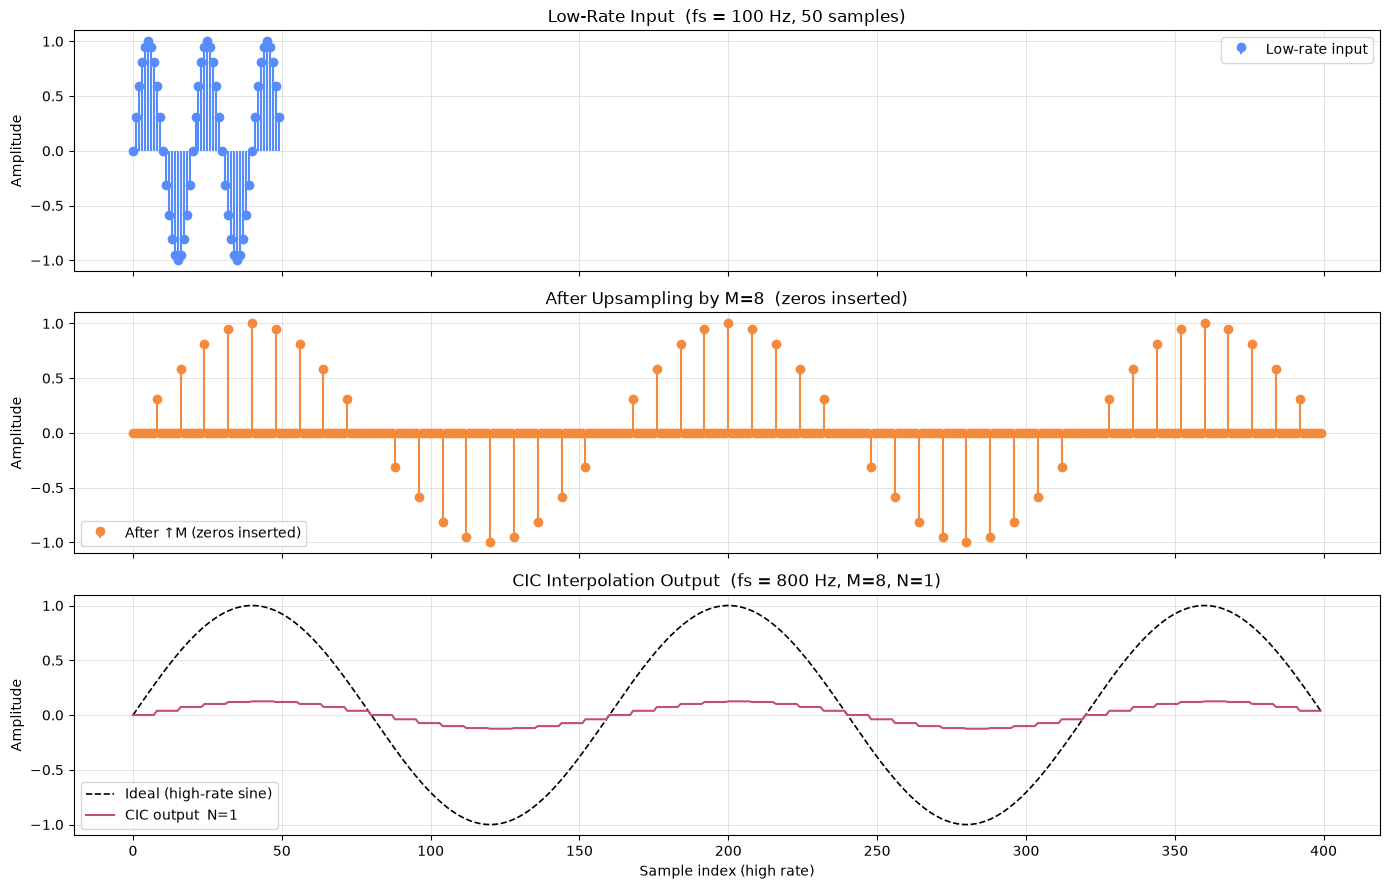

In [26]:
M = 8          # interpolation factor
N = 1          # filter order (stages)
fs_low = 100   # Hz — low sample rate
f_sig = 5      # Hz — signal frequency
T = 0.5        # seconds — duration

# Low-rate signal
n_low = np.arange(0, int(T * fs_low))
x_low = np.sin(2 * np.pi * f_sig * n_low / fs_low)

# CIC interpolated output
y_cic = cic_interp(x_low, M, N)

# Normalise gain (CIC has gain = M^N)
y_cic_norm = y_cic / (M ** N)

# Ideal reference at high rate
fs_high = fs_low * M
n_high = np.arange(0, len(y_cic))
x_ideal = np.sin(2 * np.pi * f_sig * n_high / fs_high)

# Zero-inserted signal (before filtering)
x_up = upsample(x_low, M)
n_up = np.arange(len(x_up))

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].stem(n_low, x_low, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='Low-rate input')
axes[0].set_title(f'Low-Rate Input  (fs = {fs_low} Hz, {len(n_low)} samples)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)
axes[0].legend()

axes[1].stem(n_up, x_up, linefmt='C1-', markerfmt='C1o', basefmt=' ', label='After ↑M (zeros inserted)')
axes[1].set_title(f'After Upsampling by M={M}  (zeros inserted)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True)
axes[1].legend()

axes[2].plot(n_high, x_ideal, 'k--', lw=1.2, label='Ideal (high-rate sine)')
axes[2].plot(n_high, y_cic_norm, 'C2-', lw=1.5, label=f'CIC output  N={N}')
axes[2].set_title(f'CIC Interpolation Output  (fs = {fs_high} Hz, M={M}, N={N})')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Sample index (high rate)')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

## Verify: CIC vs Moving-Average Equivalent

Both implementations must produce the same output (up to floating-point rounding).

In [27]:
y_ma = cic_interp_ma(x_low, M, N)

# Trim to same length (MA uses full convolution so may be longer)
L = min(len(y_cic), len(y_ma))
max_err = np.max(np.abs(y_cic[:L] - y_ma[:L]))
print(f'Max absolute difference between CIC and MA: {max_err:.2e}')
assert max_err < 1e-9, 'Implementations do not match!'
print('Implementations match.')

Max absolute difference between CIC and MA: 2.29e-17
Implementations match.


## Frequency Response

The CIC interpolation filter is a low-pass filter whose magnitude is:

$$\left|H(e^{j\omega})\right| = \left|\frac{\sin(M\omega/2)}{\sin(\omega/2)}\right|^N$$

- The **passband** extends up to $\omega = \pi/M$ (the original Nyquist band).
- **Images** of the baseband signal (at multiples of $\omega = 2\pi/M$) are attenuated.
- Higher order $N$ gives more image rejection at the cost of passband droop.

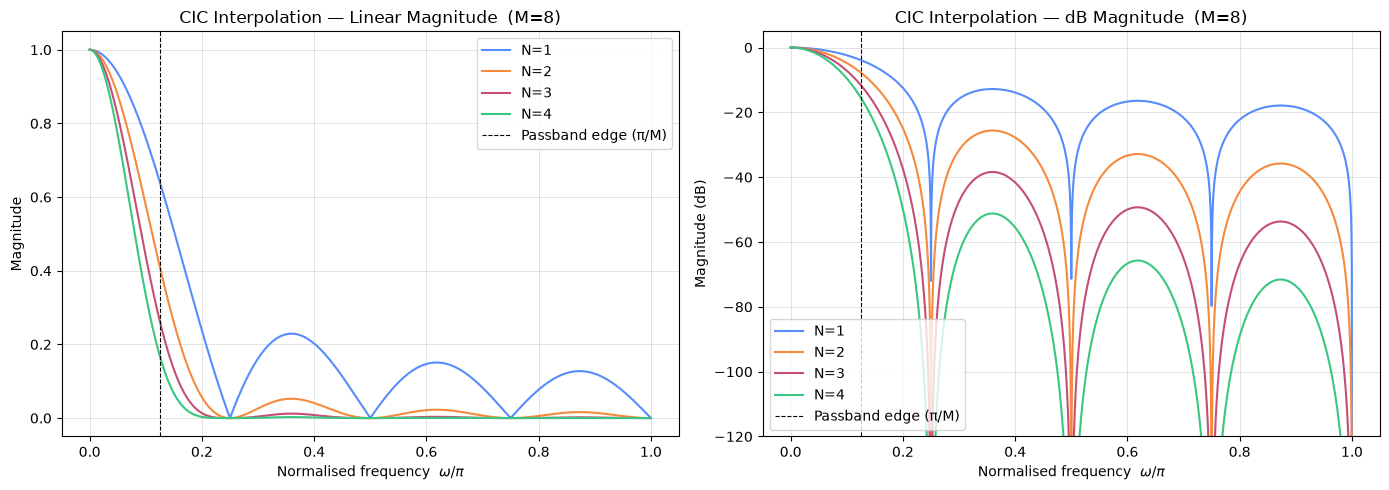

In [28]:
def cic_response(M, N, n_pts=4096):
    """Analytical CIC magnitude response (normalised to unity at DC)."""
    omega = np.linspace(0, np.pi, n_pts)
    # Avoid division by zero at omega=0
    with np.errstate(divide='ignore', invalid='ignore'):
        H = np.where(
            omega == 0,
            1.0,
            np.abs(np.sin(M * omega / 2) / np.sin(omega / 2)) ** N / (M ** N)
        )
    return omega, H


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

M_plot = 8
orders = [1, 2, 3, 4]

for N_plot in orders:
    omega, H = cic_response(M_plot, N_plot)
    axes[0].plot(omega / np.pi, H, label=f'N={N_plot}')
    axes[1].plot(omega / np.pi, 20 * np.log10(np.clip(H, 1e-10, None)), label=f'N={N_plot}')

# Mark the passband edge at pi/M
for ax in axes:
    ax.axvline(1 / M_plot, color='k', ls='--', lw=0.8, label=f'Passband edge (π/M)')
    ax.set_xlabel(r'Normalised frequency  $\omega/\pi$')
    ax.legend()
    ax.grid(True)

axes[0].set_title(f'CIC Interpolation — Linear Magnitude  (M={M_plot})')
axes[0].set_ylabel('Magnitude')

axes[1].set_title(f'CIC Interpolation — dB Magnitude  (M={M_plot})')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_ylim(-120, 5)

plt.tight_layout()
plt.show()

## Effect of Interpolation Factor M

Increasing $M$ narrows the passband (in normalised frequency) and places images closer to DC.

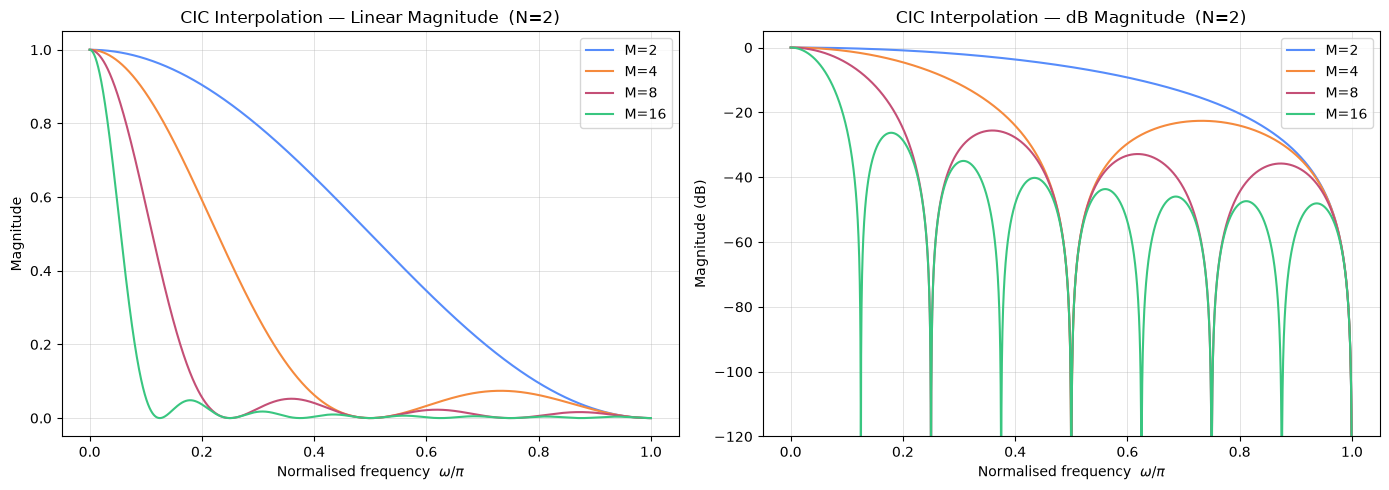

In [29]:
N_plot = 2
Ms = [2, 4, 8, 16]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for M_plot in Ms:
    omega, H = cic_response(M_plot, N_plot)
    axes[0].plot(omega / np.pi, H, label=f'M={M_plot}')
    axes[1].plot(omega / np.pi, 20 * np.log10(np.clip(H, 1e-10, None)), label=f'M={M_plot}')

for ax in axes:
    ax.set_xlabel(r'Normalised frequency  $\omega/\pi$')
    ax.legend()
    ax.grid(True)

axes[0].set_title(f'CIC Interpolation — Linear Magnitude  (N={N_plot})')
axes[0].set_ylabel('Magnitude')

axes[1].set_title(f'CIC Interpolation — dB Magnitude  (N={N_plot})')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_ylim(-120, 5)

plt.tight_layout()
plt.show()

## Multi-Stage CIC: Image Rejection

After upsampling, the spectrum of the low-rate signal repeats at multiples of $2\pi/M$ — these are called **images** and must be suppressed.

Here we show how increasing the order $N$ progressively removes images from a multi-tone input.

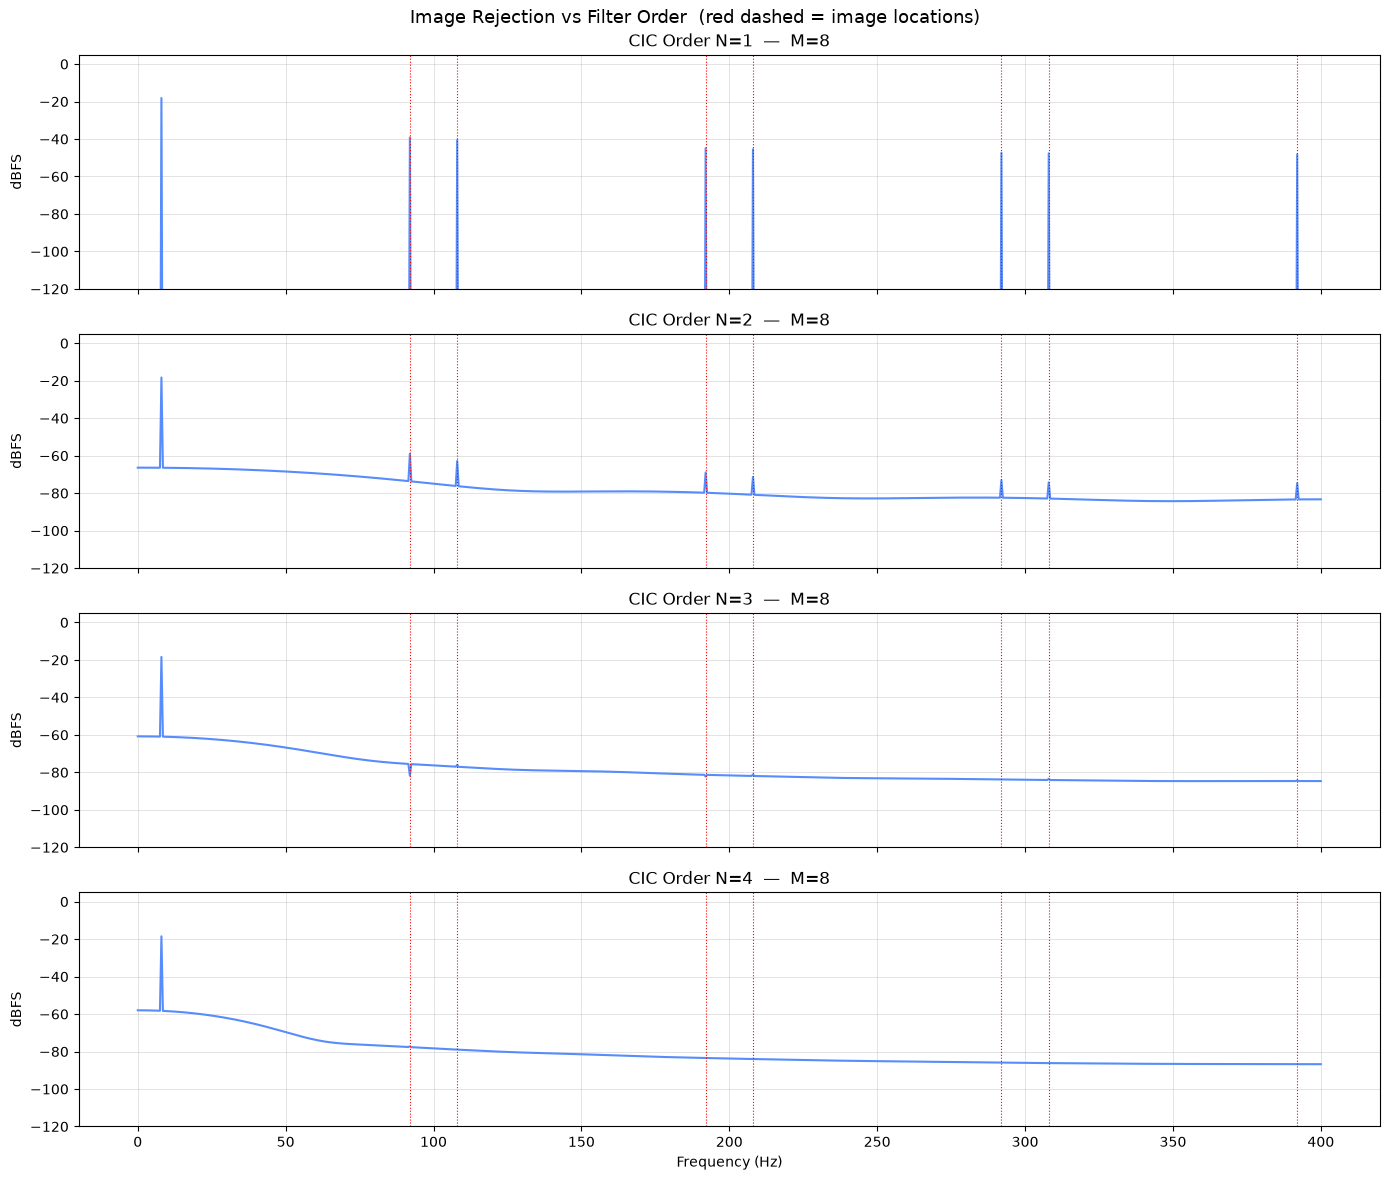

In [30]:
M = 8
fs_low = 100      # Hz
T = 2.0           # seconds (more samples → better spectral resolution)
f_sig = 8         # Hz — single tone, well within passband

n_low = np.arange(int(T * fs_low))
x_low = np.cos(2 * np.pi * f_sig * n_low / fs_low)

orders = [1, 2, 3, 4]
fig, axes = plt.subplots(len(orders), 1, figsize=(14, 12), sharex=True)

fs_high = fs_low * M

for idx, N in enumerate(orders):
    y = cic_interp(x_low, M, N)
    y_norm = y / (M ** N)

    freqs = np.fft.rfftfreq(len(y_norm), d=1.0 / fs_high)
    spectrum = 20 * np.log10(np.abs(np.fft.rfft(y_norm)) / len(y_norm) * 2 + 1e-12)

    axes[idx].plot(freqs, spectrum)
    # Mark image locations: f_sig + k*fs_low
    for k in range(1, M // 2 + 1):
        f_img = k * fs_low - f_sig
        if f_img < fs_high / 2:
            axes[idx].axvline(f_img, color='r', ls=':', lw=0.8)
        f_img2 = k * fs_low + f_sig
        if f_img2 < fs_high / 2:
            axes[idx].axvline(f_img2, color='r', ls=':', lw=0.8)

    axes[idx].set_title(f'CIC Order N={N}  —  M={M}')
    axes[idx].set_ylabel('dBFS')
    axes[idx].set_ylim(-120, 5)
    axes[idx].grid(True)

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle(f'Image Rejection vs Filter Order  (red dashed = image locations)', fontsize=13)
plt.tight_layout()
plt.show()

## Passband Droop and Compensation

The CIC response is **not flat** across the passband — it rolls off towards $\omega = \pi/M$.  
This **passband droop** is $N \cdot 20\log_{10}(\text{sinc}(f/f_s))$ dB.

A simple **compensation filter** (often called a CIC corrector) pre-emphasises the signal at the low rate to cancel the droop:

$$H_\text{comp}(\omega) = \frac{1}{|H_\text{CIC}(\omega)|} \quad \text{for } |\omega| \leq \pi/M$$

Below we show the droop quantitatively and apply a windowed sinc compensator.

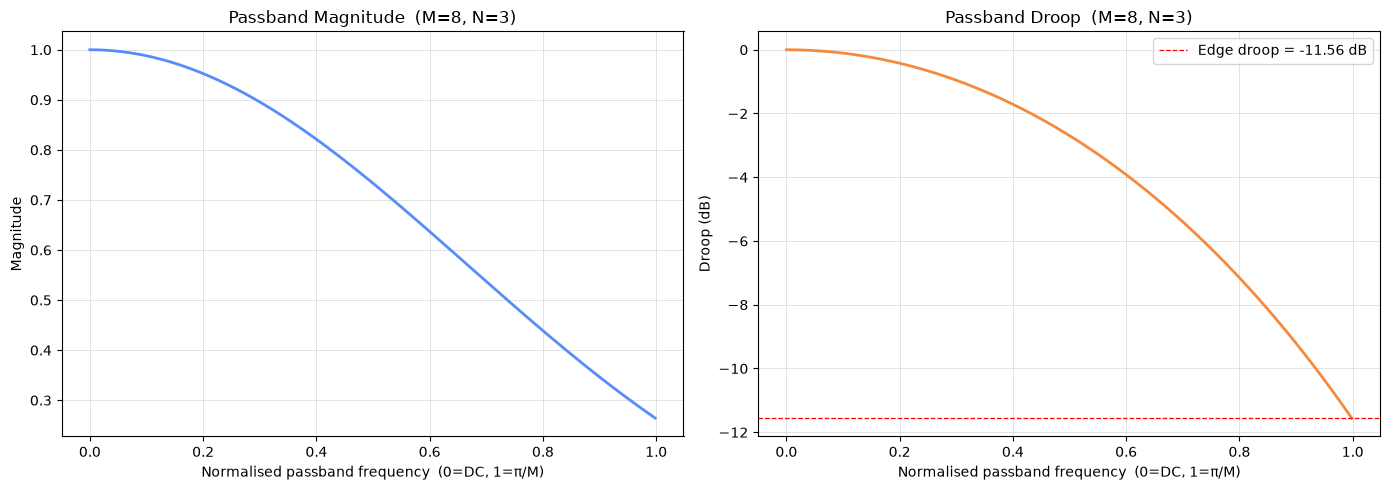

Passband droop at π/M edge: -11.556 dB


In [31]:
M = 8
N = 3

omega, H = cic_response(M, N)

# Passband only: 0 … pi/M
pb_mask = omega <= np.pi / M
omega_pb = omega[pb_mask]
H_pb = H[pb_mask]

droop_dB = 20 * np.log10(H_pb / H_pb[0])
droop_max = droop_dB[-1]  # droop at passband edge

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(omega_pb / np.pi * M, H_pb, lw=2)   # x axis: 0…1 normalised to passband
axes[0].set_title(f'Passband Magnitude  (M={M}, N={N})')
axes[0].set_xlabel('Normalised passband frequency  (0=DC, 1=π/M)')
axes[0].set_ylabel('Magnitude')
axes[0].grid(True)

axes[1].plot(omega_pb / np.pi * M, droop_dB, lw=2, color='C1')
axes[1].axhline(droop_max, color='r', ls='--', lw=0.9, label=f'Edge droop = {droop_max:.2f} dB')
axes[1].set_title(f'Passband Droop  (M={M}, N={N})')
axes[1].set_xlabel('Normalised passband frequency  (0=DC, 1=π/M)')
axes[1].set_ylabel('Droop (dB)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Passband droop at π/M edge: {droop_max:.3f} dB')

## Full Pipeline: Multi-Stage CIC Interpolation

A realistic scenario: low-rate baseband signal → CIC × N stages → high-rate output.

We compare orders N=1 through 4 on the same input and measure RMS error vs the ideal reference.

In [ ]:
M = 8
fs_low = 100
fs_high = fs_low * M
T = 0.3
f_sig = 6   # Hz — well within passband

n_low = np.arange(int(T * fs_low))
x_low = np.sin(2 * np.pi * f_sig * n_low / fs_low)

# Ideal reference
n_high = np.arange(int(T * fs_high))
x_ideal = np.sin(2 * np.pi * f_sig * n_high / fs_high)

orders = [1, 2, 3, 4]
fig, axes = plt.subplots(len(orders), 1, figsize=(14, 12), sharex=True)

for idx, N in enumerate(orders):
    y = cic_interp(x_low, M, N) / (M ** N)
    L = min(len(y), len(x_ideal))
    rms_err = np.sqrt(np.mean((y[:L] - x_ideal[:L]) ** 2))

    axes[idx].plot(n_high[:L], x_ideal[:L], 'k--', lw=1.2, label='Ideal')
    axes[idx].plot(n_high[:L], y[:L], lw=1.5, label=f'CIC N={N}  (RMS err={rms_err:.4f})')
    axes[idx].set_ylabel('Amplitude')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True)
    axes[idx].set_title(f'N={N} stages')

axes[-1].set_xlabel('Sample index (high rate)')
fig.suptitle(f'CIC Interpolation — Order Comparison  (M={M}, f_sig={f_sig} Hz)', fontsize=13)
plt.tight_layout()
plt.show()

## Summary

| Parameter | Effect |
|-----------|--------|
| **M** (interpolation factor) | Sets the output-to-input rate ratio; higher M narrows passband |
| **N** (filter order / stages) | More stages → steeper roll-off, more image rejection, more passband droop |
| **Gain** | The filter has gain $M^N$ at DC — normalise before use |
| **Group delay** | Approximately $N(M-1)/2$ output samples |

**Trade-offs:**
- Increasing $N$ improves image rejection but increases passband droop and latency.
- In practice a CIC corrector FIR filter is added after the CIC to flatten the passband.
- CIC filters contain **no multipliers** (only accumulators and subtractors), making them ideal for FPGA/ASIC implementations at very high clock rates.